Training shape: (8143, 7)
Test 1 shape: (2665, 7)
Test 2 shape: (9752, 7)

Missing values in training data:
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
dtype: int64

Missing values in Test 1:
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
dtype: int64

Missing values in Test 2:
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
dtype: int64

Training Time: 0.7855 seconds

XGBOOST - TEST 1 RESULTS
Accuracy : 95.0469 %
Precision: 94.0252 %
Recall   : 92.284 %
F1-score : 93.1464 %
ROC-AUC  : 98.9694 %

Classification Report:
              precision    recall  f1-score   support

  Unoccupied       0.96      0.97      0.96      1693
    Occupied       0.94      0.92      0.93       972

    accuracy                           0.95      2665
   macro avg       0.95      0.94      0.95      2665
weighted avg       0.95      0.95      0.95      2665


X

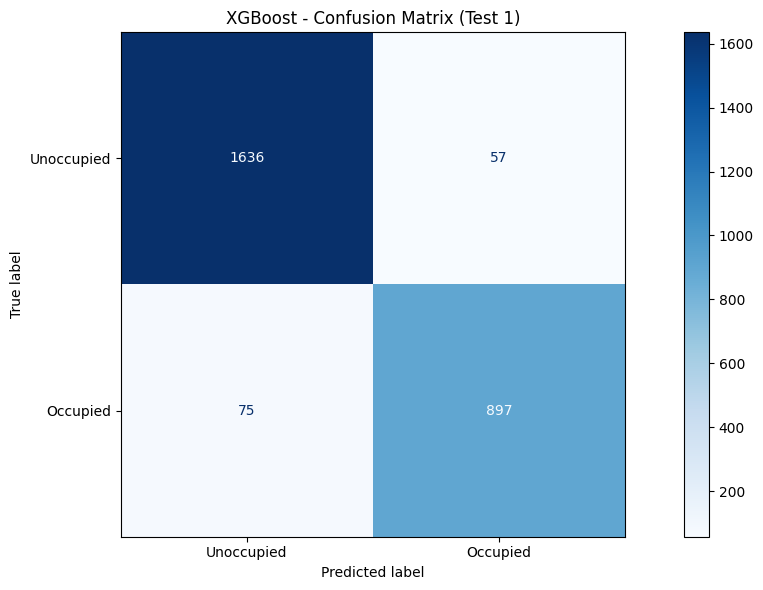

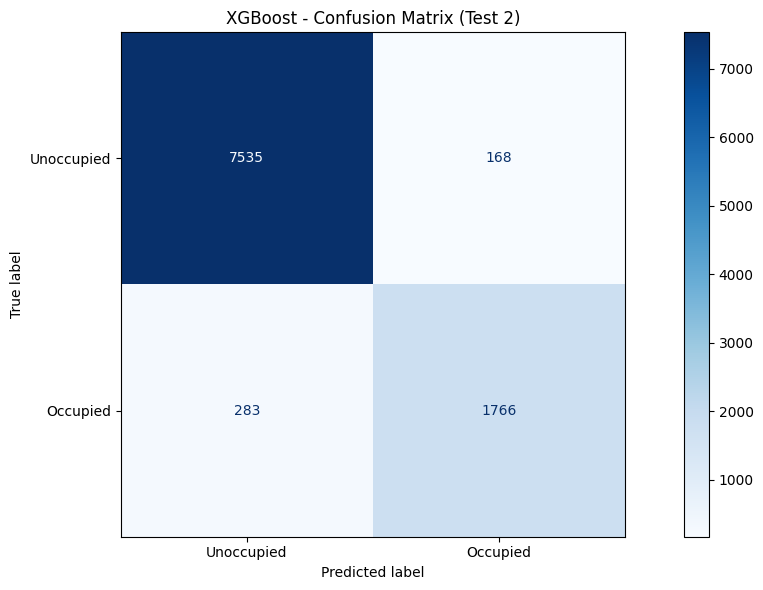


XGBOOST FEATURE IMPORTANCE
         Feature  Importance
2          Light    0.915575
3            CO2    0.035067
0    Temperature    0.020422
1       Humidity    0.015902
4  HumidityRatio    0.013034


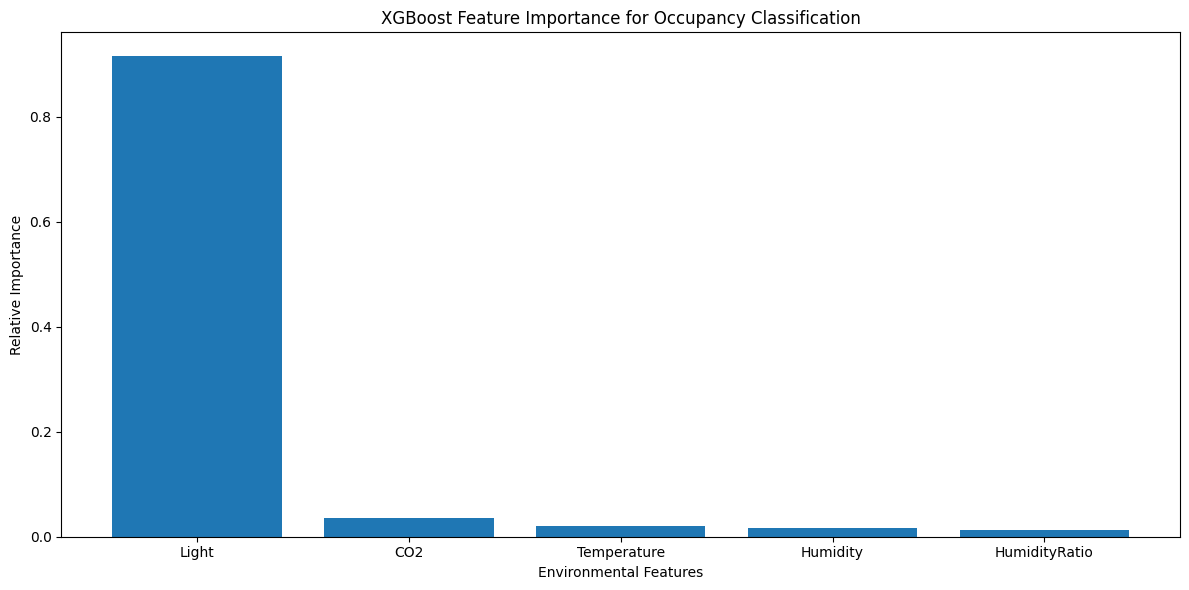


Results saved successfully.

FINAL XGBOOST SUMMARY
Training Time: 0.7855 seconds

Test 1:
Accuracy : 95.05 %
Precision: 94.03 %
Recall   : 92.28 %
F1       : 93.15 %
ROC-AUC  : 98.97 %

Test 2:
Accuracy : 95.38 %
Precision: 91.31 %
Recall   : 86.19 %
F1       : 88.68 %
ROC-AUC  : 99.02 %


In [2]:
# ============================================
# PERSON 3 - XGBOOST OCCUPANCY DETECTION
# ============================================

# If XGBoost is not installed, run this once:
# !pip install xgboost


# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# ============================================
# 2. LOAD DATASET
# ============================================

train_path = "/content/datatraining.txt"
test1_path = "/content/datatest.txt"
test2_path = "/content/datatest2.txt"

train_df = pd.read_csv(train_path)
test1_df = pd.read_csv(test1_path)
test2_df = pd.read_csv(test2_path)

print("Training shape:", train_df.shape)
print("Test 1 shape:", test1_df.shape)
print("Test 2 shape:", test2_df.shape)


# ============================================
# 3. SELECT FEATURES AND TARGET
# ============================================

FEATURES = [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio"
]

TARGET = "Occupancy"

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test1 = test1_df[FEATURES]
y_test1 = test1_df[TARGET]

X_test2 = test2_df[FEATURES]
y_test2 = test2_df[TARGET]


# ============================================
# 4. CHECK MISSING VALUES
# ============================================

print("\nMissing values in training data:")
print(X_train.isnull().sum())

print("\nMissing values in Test 1:")
print(X_test1.isnull().sum())

print("\nMissing values in Test 2:")
print(X_test2.isnull().sum())


# ============================================
# 5. CREATE XGBOOST MODEL
# ============================================

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)


# ============================================
# 6. TRAIN MODEL + TRAINING TIME
# ============================================

start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print("\nTraining Time:",
      round(training_time, 4), "seconds")


# ============================================
# 7. PREDICTIONS
# ============================================

# Test 1
y_pred_test1 = model.predict(X_test1)
y_prob_test1 = model.predict_proba(X_test1)[:, 1]

# Test 2
y_pred_test2 = model.predict(X_test2)
y_prob_test2 = model.predict_proba(X_test2)[:, 1]


# ============================================
# 8. TEST 1 METRICS
# ============================================

accuracy1 = accuracy_score(y_test1, y_pred_test1)
precision1 = precision_score(
    y_test1,
    y_pred_test1,
    zero_division=0
)
recall1 = recall_score(
    y_test1,
    y_pred_test1,
    zero_division=0
)
f1_1 = f1_score(
    y_test1,
    y_pred_test1,
    zero_division=0
)
auc1 = roc_auc_score(y_test1, y_prob_test1)

print("\n================================")
print("XGBOOST - TEST 1 RESULTS")
print("================================")

print("Accuracy :", round(accuracy1 * 100, 4), "%")
print("Precision:", round(precision1 * 100, 4), "%")
print("Recall   :", round(recall1 * 100, 4), "%")
print("F1-score :", round(f1_1 * 100, 4), "%")
print("ROC-AUC  :", round(auc1 * 100, 4), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test1,
        y_pred_test1,
        target_names=["Unoccupied", "Occupied"]
    )
)


# ============================================
# 9. TEST 2 METRICS
# ============================================

accuracy2 = accuracy_score(y_test2, y_pred_test2)
precision2 = precision_score(
    y_test2,
    y_pred_test2,
    zero_division=0
)
recall2 = recall_score(
    y_test2,
    y_pred_test2,
    zero_division=0
)
f1_2 = f1_score(
    y_test2,
    y_pred_test2,
    zero_division=0
)
auc2 = roc_auc_score(y_test2, y_prob_test2)

print("\n================================")
print("XGBOOST - TEST 2 RESULTS")
print("================================")

print("Accuracy :", round(accuracy2 * 100, 4), "%")
print("Precision:", round(precision2 * 100, 4), "%")
print("Recall   :", round(recall2 * 100, 4), "%")
print("F1-score :", round(f1_2 * 100, 4), "%")
print("ROC-AUC  :", round(auc2 * 100, 4), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test2,
        y_pred_test2,
        target_names=["Unoccupied", "Occupied"]
    )
)


# ============================================
# 10. CREATE RESULTS DIRECTORY
# ============================================

os.makedirs(
    "../results/xgboost",
    exist_ok=True
)


# ============================================
# 11. CONFUSION MATRIX - TEST 1
# ============================================

cm_test1 = confusion_matrix(
    y_test1,
    y_pred_test1
)

fig, ax = plt.subplots(figsize=(12, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test1,
    display_labels=[
        "Unoccupied",
        "Occupied"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

ax.set_title(
    "XGBoost - Confusion Matrix (Test 1)"
)

plt.tight_layout()

plt.savefig(
    "../results/xgboost/confusion_matrix_test1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 12. CONFUSION MATRIX - TEST 2
# ============================================

cm_test2 = confusion_matrix(
    y_test2,
    y_pred_test2
)

fig, ax = plt.subplots(figsize=(12, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test2,
    display_labels=[
        "Unoccupied",
        "Occupied"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues"
)

ax.set_title(
    "XGBoost - Confusion Matrix (Test 2)"
)

plt.tight_layout()

plt.savefig(
    "../results/xgboost/confusion_matrix_test2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 13. XGBOOST FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print("\n================================")
print("XGBOOST FEATURE IMPORTANCE")
print("================================")

print(importance_df)


# ============================================
# 14. FEATURE IMPORTANCE GRAPH
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax.set_xlabel(
    "Environmental Features"
)

ax.set_ylabel(
    "Relative Importance"
)

ax.set_title(
    "XGBoost Feature Importance for Occupancy Classification"
)

plt.tight_layout()

plt.savefig(
    "../results/xgboost/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================
# 15. SAVE RESULTS TO CSV
# ============================================

results = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Test Set": "Test 1",
        "Accuracy": accuracy1,
        "Precision": precision1,
        "Recall": recall1,
        "F1": f1_1,
        "ROC-AUC": auc1,
        "Training Time (seconds)": training_time
    },
    {
        "Model": "XGBoost",
        "Test Set": "Test 2",
        "Accuracy": accuracy2,
        "Precision": precision2,
        "Recall": recall2,
        "F1": f1_2,
        "ROC-AUC": auc2,
        "Training Time (seconds)": training_time
    }
])

results.to_csv(
    "../results/xgboost/results.csv",
    index=False
)

print("\nResults saved successfully.")


# ============================================
# 16. FINAL SUMMARY
# ============================================

print("\n================================")
print("FINAL XGBOOST SUMMARY")
print("================================")

print("Training Time:",
      round(training_time, 4), "seconds")

print("\nTest 1:")
print("Accuracy :", round(accuracy1 * 100, 2), "%")
print("Precision:", round(precision1 * 100, 2), "%")
print("Recall   :", round(recall1 * 100, 2), "%")
print("F1       :", round(f1_1 * 100, 2), "%")
print("ROC-AUC  :", round(auc1 * 100, 2), "%")

print("\nTest 2:")
print("Accuracy :", round(accuracy2 * 100, 2), "%")
print("Precision:", round(precision2 * 100, 2), "%")
print("Recall   :", round(recall2 * 100, 2), "%")
print("F1       :", round(f1_2 * 100, 2), "%")
print("ROC-AUC  :", round(auc2 * 100, 2), "%")